Author(s) : Elisabet Verger-Miralles and Laura Gómez Navarro

Objective: Describe xxx

Created on: May 2024

Last updated on:


In [1]:
import time

print(time.ctime(time.time()))

Sun Jun 16 21:43:48 2024


In [2]:
import sys
sys.path.insert(0, "../../../processing/")

In [3]:
import numpy as np
import xarray as xr # version 0.20.1 necesarry, 0.16 gives error when calculating u_for
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal import butter, filtfilt

import cartopy
import cartopy.crs as ccrs
import cartopy.feature       as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

from read_data_tools import latlon2uv_dir

In [4]:
# version_information

In [5]:
print(xr.__version__)

2023.6.0


# Parameters:

In [6]:
savedir_figs = '../../proc_figures/'

# 1. Loading data

(processed here: /Users/Gomez023/src/git/FaSt-SWOT/code/data_processing/drifters/processing/SVPB_processing/)

In [7]:
!ls ../../../../../../data/drifters/L1_IMEDEA/*car*

../../../../../../data/drifters/L1_IMEDEA/drifter_carthe006-ime_carthe001.nc
../../../../../../data/drifters/L1_IMEDEA/drifter_carthe007-ime_carthe002.nc
../../../../../../data/drifters/L1_IMEDEA/drifter_carthe008-ime_carthe003.nc
../../../../../../data/drifters/L1_IMEDEA/drifter_carthe009-ime_carthe004.nc
../../../../../../data/drifters/L1_IMEDEA/drifter_carthe010-ime_carthe005.nc
../../../../../../data/drifters/L1_IMEDEA/drifter_carthe011-ime_carthe006.nc
../../../../../../data/drifters/L1_IMEDEA/drifter_carthe012-ime_carthe007.nc
../../../../../../data/drifters/L1_IMEDEA/drifter_carthe013-ime_carthe008.nc
../../../../../../data/drifters/L1_IMEDEA/drifter_carthe014-ime_carthe009.nc
../../../../../../data/drifters/L1_IMEDEA/drifter_carthe015-ime_carthe010.nc
../../../../../../data/drifters/L1_IMEDEA/drifter_carthe016-ime_carthe011.nc
../../../../../../data/drifters/L1_IMEDEA/drifter_carthe017-ime_carthe012.nc
../../../../../../data/drifters/L1_IMEDEA/drifter_carthe018-ime_carthe013.nc

In [8]:
# url_drifter = "drifter_svpb040-scb_svpb040/L0/2023/dep0001_drifter-svpb040_scb-svpb040_L0_2023-04-26.nc?"

rootdir = '../../../../../../'
outdir = 'data/drifters/L1_IMEDEA/'

# outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
# outname = outname.split('_')[1]
drifter_num=3
outname = 'drifter_carthe007-ime_carthe002'

## Opening netcdf:

In [9]:
ds = xr.open_dataset(rootdir + outdir + outname + '.nc')

In [10]:
ds

<xarray.Dataset>
Dimensions:     (time: 1900)
Coordinates:
    DEPTH       float64 ...
  * time        (time) datetime64[ns] 2023-04-26T14:00:00 ... 2023-05-09T18:3...
Data variables:
    BAT_STATUS  (time) float64 ...
    LAT         (time) float64 ...
    LON         (time) float64 ...
    U           (time) float64 ...
    V           (time) float64 ...
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE002 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE002 in FaSt-...
    summary:                             Deployment of IME-CARTHE002 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

# 2. Plotting outputs

In [11]:
map_extent=[-0.3, 7.9, 37.9, 41.5]
fsize=14

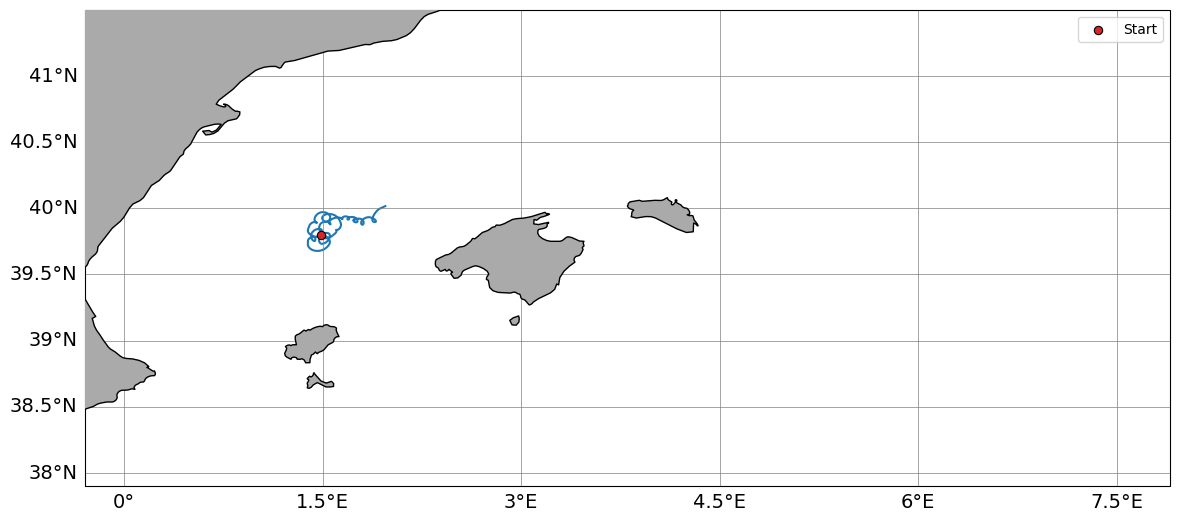

In [12]:
fig = plt.figure(figsize=(14,8))

ax1 = plt.subplot(111, projection=ccrs.PlateCarree())


#############
# Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize}#, 'color': 'gray'}
#############

ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
ax1.scatter(ds.LON[0], ds.LAT[0], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree(), label='Start', zorder=50)

ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
ax1.legend()
# ax1.set_title('Trajectory of ' + ds.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

# outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
# outname = outname.split('_')[1]

# plt.savefig(savedir_figs + 'traj_proc_' + outname + '.png', dpi=300)

plt.show()

## Velocity:

In [13]:
thresa = .1
map_extent_zoom = [ds.LON.min().values - thresa, ds.LON.max().values + thresa, ds.LAT.min().values - thresa, ds.LAT.max().values + thresa]

In [14]:
abs_vel = (ds.U**2 + ds.V**2)**0.5

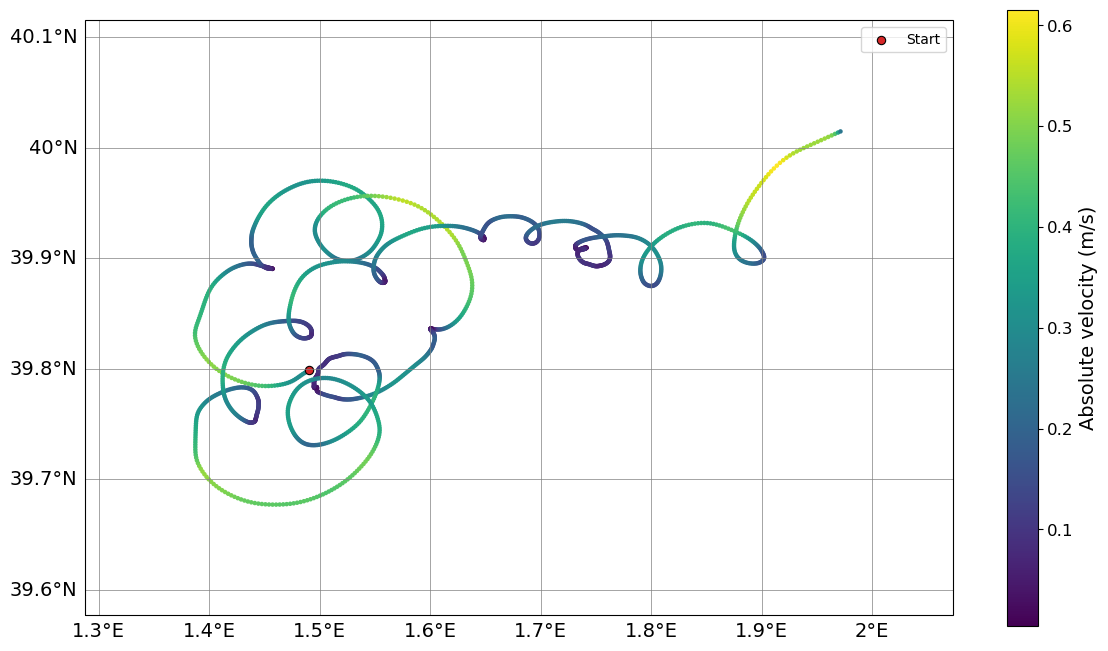

In [15]:
fig = plt.figure(figsize=(14,8))

ax1 = plt.subplot(111, projection=ccrs.PlateCarree())


#############
# Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize}#, 'color': 'gray'}
#############

cc = ax1.scatter(ds.LON, ds.LAT, s=5, c=abs_vel, transform=ccrs.PlateCarree())
ax1.scatter(ds.LON[0], ds.LAT[0], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree()
            , label='Start')
cbar = plt.colorbar(cc)
cbar_label = r'Absolute velocity (m/s)'
cbar.ax.tick_params(labelsize=fsize-2)
cbar.ax.set_ylabel(cbar_label, fontsize=fsize)

ax1.set_extent(map_extent_zoom, crs=ccrs.PlateCarree())
ax1.legend()
# ax1.set_title(ds05.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

# outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# # --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
# outname = outname.split('_')[1]

plt.savefig(savedir_figs + 'traj_proc_vels_' + outname + '.png', dpi=300)

plt.show()

# Filtering inertial osc.:

In [16]:
def butter_highpass_filter(data, cutoff, fs, order=5):
    """
    Aplica un filtro Butterworth de paso alto.
   
        Args:
        - data: Array de datos a filtrar.
        - cutoff: Frecuencia de corte del filtro.
        - fs: Frecuencia de muestreo de los datos.
        - order: Orden del filtro.
    
        Returns:
        - y: Datos filtrados.
    
    """
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

In [17]:
ds.time

<xarray.DataArray 'time' (time: 1900)>
array(['2023-04-26T14:00:00.000000000', '2023-04-26T14:10:00.000000000',
       '2023-04-26T14:20:00.000000000', ..., '2023-05-09T18:10:00.000000000',
       '2023-05-09T18:20:00.000000000', '2023-05-09T18:30:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    DEPTH    float64 ...
  * time     (time) datetime64[ns] 2023-04-26T14:00:00 ... 2023-05-09T18:30:00
Attributes:
    standard_name:  time
    axis:           T

In [18]:
cuttof_frequency = 1/36. # 31 hores
fs = 6. # mostreig cada 10 mins en comptes de 1h!

In [19]:
# --> double check params!

In [20]:
lon_filtered = butter_highpass_filter(ds.LON, cuttof_frequency, fs)
lat_filtered = butter_highpass_filter(ds.LAT, cuttof_frequency, fs)

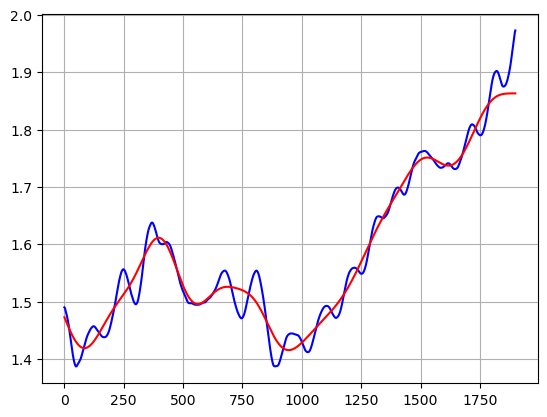

In [21]:
plt.figure()
plt.plot(ds.LON, c='b')
plt.plot(lon_filtered, c='r')
plt.grid()
plt.show()

# --> looks good!

## New dataset:

In [22]:
ds_f = ds.copy(deep=True)

In [23]:
ds_f['LON'][:] = lon_filtered
ds_f['LAT'][:] = lat_filtered

# Replotting in space:

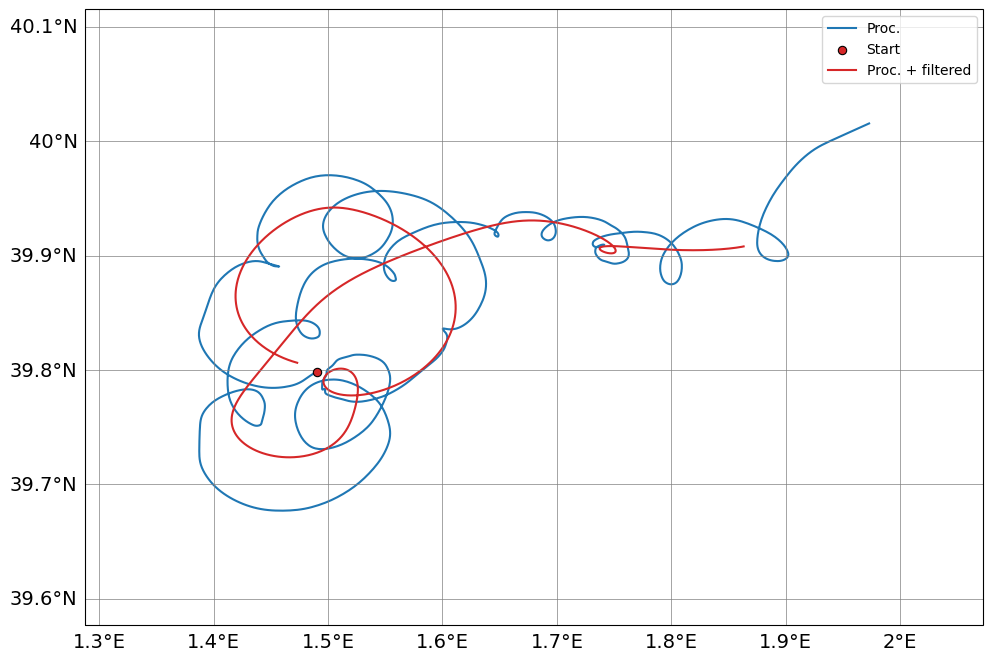

In [24]:
fig = plt.figure(figsize=(14,8))

ax1 = plt.subplot(111, projection=ccrs.PlateCarree())


#############
# Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize}#, 'color': 'gray'}
#############

ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0', label='Proc.') 
ax1.scatter(ds.LON[0], ds.LAT[0], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree(), label='Start', zorder=50)
ax1.plot(ds_f.LON, ds_f.LAT, transform=ccrs.PlateCarree(), c='C3', label='Proc. + filtered') 

ax1.set_extent(map_extent_zoom, crs=ccrs.PlateCarree())
ax1.legend()
# ax1.set_title('Trajectory of ' + ds.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

# plt.savefig(savedir_figs + 'traj_proc_' + outname + '.png', dpi=300)

plt.show()

# --> ok

# Recalculating U and V:

In [25]:
temp_res = 3600. # 1 hour in seconds (double-check this value still ok here)

In [26]:
speed, ufor, vfor = latlon2uv_dir(ds_f.LAT, ds_f.LON, temp_res, 'forward')
_, uback, vback = latlon2uv_dir(ds_f.LAT, ds_f.LON, temp_res, 'back')

In [27]:
# Calculate central value
u = (ufor + uback) / 2
v = (vfor + vback) / 2

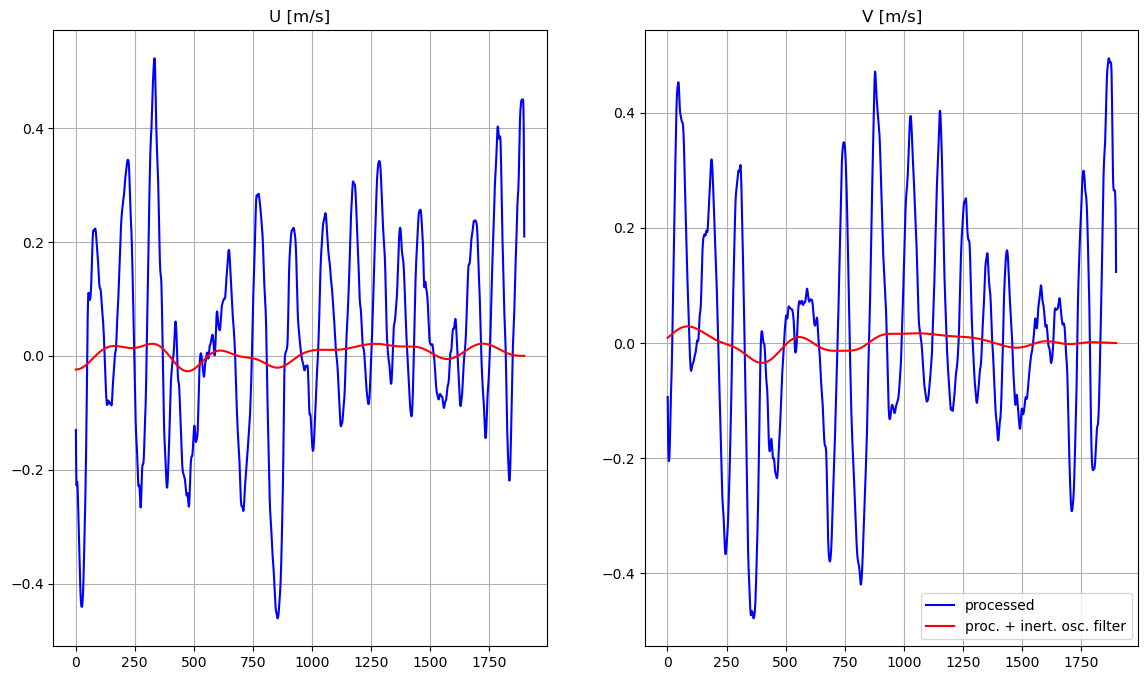

In [28]:
plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
plt.plot(ds.U, c='b')
plt.plot(u, c='r')
plt.title('U [m/s]')
plt.grid()

plt.subplot(1,2,2)
plt.plot(ds.V, c='b', label='processed')
plt.plot(v, c='r', label='proc. + inert. osc. filter')
plt.grid()
plt.title('V [m/s]')
plt.legend(loc=0)
plt.show()

## Assigning new U and V values:

In [29]:
ds_f['U'][:] = u
ds_f['V'][:] = v

# Saving:

In [30]:
ds_f

<xarray.Dataset>
Dimensions:     (time: 1900)
Coordinates:
    DEPTH       float64 ...
  * time        (time) datetime64[ns] 2023-04-26T14:00:00 ... 2023-05-09T18:3...
Data variables:
    BAT_STATUS  (time) float64 ...
    LAT         (time) float64 39.81 39.81 39.81 39.81 ... 39.91 39.91 39.91
    LON         (time) float64 1.473 1.472 1.471 1.47 ... 1.863 1.863 1.863
    U           (time) float64 nan -0.02395 -0.02395 ... 7.489e-06 5.858e-06 nan
    V           (time) float64 nan 0.009173 0.009521 ... 2.846e-06 2.242e-06 nan
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE002 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE002 in FaSt-...
    summary:                             Deployment of IME-CARTHE002 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

In [31]:
outdir_an = "/Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/"
# add hereon

In [32]:
outname

'drifter_carthe007-ime_carthe002'

In [33]:
ds_f.to_netcdf(outdir_an + outname + '_inertial_osc_filt' + '.nc')

In [34]:
!ls /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/


drifter_carthe006-ime_carthe001_inertial_osc_filt.nc
drifter_carthe007-ime_carthe002_inertial_osc_filt.nc


# Looking at 4 days of leg 1 campaign:

In [35]:
ds_s = ds.sel(time=slice("2023-04-26 00:00", "2023-05-02 23:59"))
ds_f_s = ds_f.sel(time=slice("2023-04-26 00:00", "2023-05-02 23:59"))


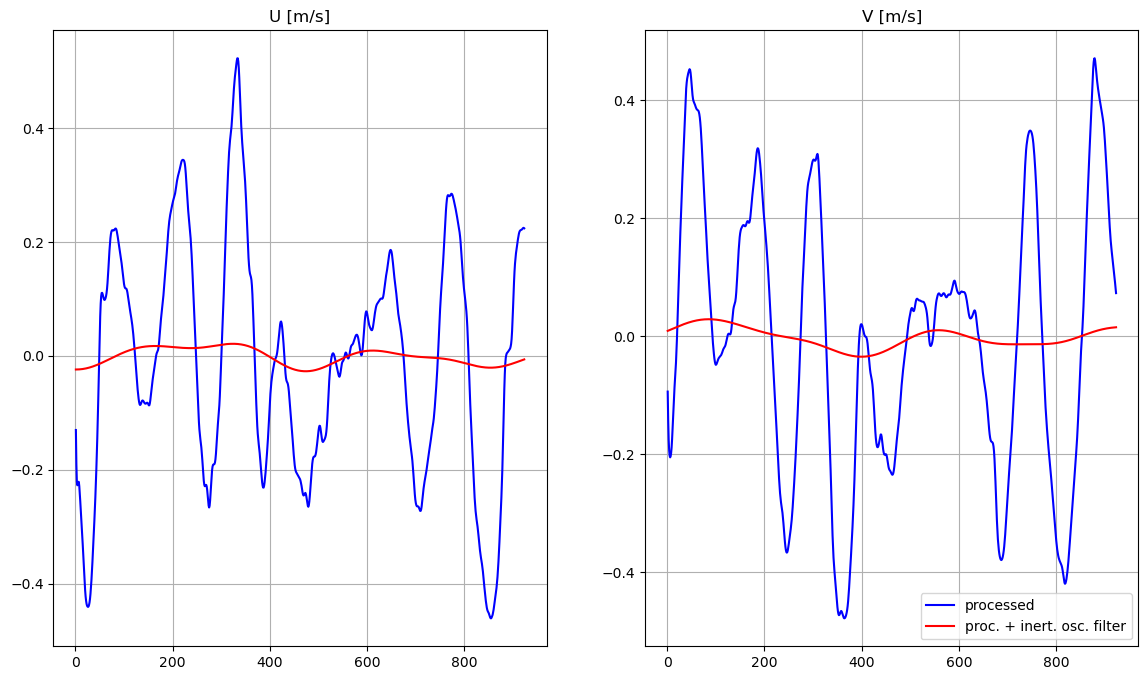

In [36]:
plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
plt.plot(ds_s.U, c='b')
plt.plot(ds_f_s.U, c='r')
plt.title('U [m/s]')
plt.grid()

plt.subplot(1,2,2)
plt.plot(ds_s.V, c='b', label='processed')
plt.plot(ds_f_s.V, c='r', label='proc. + inert. osc. filter')
plt.grid()
plt.title('V [m/s]')
plt.legend(loc=0)
plt.show()